In [2]:
import re
from pathlib import Path 

import cv2
import IPython
import numpy as np
import pandas as pd
from tqdm import tqdm 

In [3]:
def distance_from_center(row):
    x = int((((row['x2'] - row['x1'])/2) + row['x1']) * row['img_width'])
    y = int((((row['y2'] - row['y1'])/2) + row['y1']) * row['img_height'])
    
    xx = int(row['img_width']/2)
    yy = int(row['img_height']/2)
    
    a = abs(yy - y) 
    b = abs(xx - x)
    c = np.sqrt(a*a + b*b)
    return round(c, 2) 

In [4]:
def pct_of_frame(row):
    x = int((row['x2'] - row['x1']) * row['img_width'])
    y = int((row['y2'] - row['y1']) * row['img_height'])
    xx = row['img_width']
    yy = row['img_height']

    pct_of_frame = (x * y)/(xx * yy)
    return round(pct_of_frame * 100, 2) 

In [5]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [6]:
def draw_to_center(row):
    cap = cv2.VideoCapture(row['filepath'])
    cap.set(cv2.CAP_PROP_POS_FRAMES, row['frame_num'])
    ret, frame = cap.read()
    x = int((((row['x2'] - row['x1'])/2) + row['x1']) * row['img_width'])
    y = int((((row['y2'] - row['y1'])/2) + row['y1']) * row['img_height'])
    
    xx = int(row['img_width']/2)
    yy = int(row['img_height']/2)

    cv2.circle(frame, (x,y), 5, (0, 0, 255), -1)
    cv2.circle(frame, (xx,yy), 5, (0, 0, 255), -1)
    cv2.line(frame, (x,y), (xx,yy), (0, 0, 255), 2)
    distance = distance_from_center(row)
    print(distance)
    print(distance * row['img'])
    show_image(frame)

In [28]:
def get_episode_info(path):
    temp = re.findall(r'.*(S[0-9]{1,2}E[0-9]{1,2}).*', path.stem, re.I)[0]
    season = int(temp[1:3])
    episode = int(temp[4:6])
    return season, episode

In [7]:
subdirs = [x for x in Path('../data/faces').iterdir()]

In [19]:
files = [x for x in subdirs[0].iterdir()]
file = files[0]
file

PosixPath('../data/faces/king-of-the-hill_1997_118375/King.of.the.Hill.S08E05.Flirting.with.the.Master.480p.DVDRip.10bit.x265.HEVC.DD2.0-PHOCiS.csv')

In [15]:
temp = re.findall(r'.*(S[0-9]{1,2}E[0-9]{1,2}).*', file.stem, re.I)
temp

['S08E05']

In [29]:
for subdir in tqdm(subdirs):
    files = [x for x in subdir.iterdir()]
    for file in tqdm(files, leave=False):
        df = pd.read_csv(str(file), index_col=0)
        try:
            season, episode = get_episode_info(file)
        except IndexError:
            print(file)
        df['season'] = season 
        df['episode'] = episode 
        df.to_csv(str(file))

100%|██████████| 25/25 [01:58<00:00,  4.75s/it]


In [9]:
df = pd.read_csv(files[1], index_col=0)
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,frame_num,img_width,img_height,filepath,encoding,series_id,episode_id,filename,distance_from_center,pct_of_frame
0,0.241,0.112,0.558,0.938,0.358,0.390,0.496,0.444,0.430,0.598,...,432,1920,960,/home/amos/media/tv/For.All.Mankind.S01-S03.10...,-0.119807\n0.115922\n0.039224\n0.036903\n-0.07...,7772588,NaN,For.All.Mankind.S03E10.1080p.WEBRip.x265-RARBG...,194.49,26.12
1,0.328,0.176,0.641,0.998,0.447,0.477,0.583,0.510,0.524,0.690,...,456,1920,960,/home/amos/media/tv/For.All.Mankind.S01-S03.10...,-0.114525\n0.112782\n0.0280279\n-0.00757489\n-...,7772588,NaN,For.All.Mankind.S03E10.1080p.WEBRip.x265-RARBG...,88.26,25.68
2,0.260,0.120,0.584,0.991,0.398,0.413,0.534,0.459,0.485,0.620,...,504,1920,960,/home/amos/media/tv/For.All.Mankind.S01-S03.10...,-0.0558497\n0.0902229\n0.0016422\n0.0141423\n-...,7772588,NaN,For.All.Mankind.S03E10.1080p.WEBRip.x265-RARBG...,159.09,28.21
3,0.338,0.051,0.672,0.922,0.483,0.344,0.621,0.425,0.561,0.558,...,528,1920,960,/home/amos/media/tv/For.All.Mankind.S01-S03.10...,-0.0780547\n0.0999012\n0.00648193\n-0.0144452\...,7772588,NaN,For.All.Mankind.S03E10.1080p.WEBRip.x265-RARBG...,15.81,29.07
4,0.355,0.156,0.543,0.712,0.392,0.367,0.478,0.377,0.418,0.491,...,576,1920,960,/home/amos/media/tv/For.All.Mankind.S01-S03.10...,-0.0500331\n0.0732977\n0.103114\n0.0242911\n-0...,7772588,NaN,For.All.Mankind.S03E10.1080p.WEBRip.x265-RARBG...,117.05,10.41


In [40]:
df['distance_from_center'] = df.apply(distance_from_center, axis=1)
df['pct_of_frame'] = df.apply(pct_of_frame, axis=1)
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,frame_num,img_width,img_height,filepath,encoding,series_id,episode_id,filename,distance_from_center,pct_of_frame
0,0.330,0.141,0.365,0.262,0.358,0.184,0.358,0.186,0.363,0.210,...,72,1920,1080,/home/amos/media/tv/modern_family/Modern.Famil...,-0.0787058\n0.0637454\n0.10713\n-0.0302763\n-0...,1442437,NaN,Modern.Family.S01E24.1080p.BluRay.x265-RARBG.mp4,436.09,0.42
1,0.349,0.166,0.383,0.283,0.377,0.212,0.378,0.212,0.382,0.237,...,96,1920,1080,/home/amos/media/tv/modern_family/Modern.Famil...,-0.080099\n0.0411208\n0.0855177\n-0.0334313\n-...,1442437,NaN,Modern.Family.S01E24.1080p.BluRay.x265-RARBG.mp4,394.17,0.39
2,0.376,0.177,0.451,0.355,0.418,0.251,0.445,0.252,0.441,0.289,...,144,1920,1080,/home/amos/media/tv/modern_family/Modern.Famil...,-0.0840463\n0.149279\n0.0610912\n-0.0561544\n-...,1442437,NaN,Modern.Family.S01E24.1080p.BluRay.x265-RARBG.mp4,303.15,1.33
3,0.522,0.222,0.643,0.500,0.543,0.322,0.598,0.326,0.556,0.354,...,168,1920,1080,/home/amos/media/tv/modern_family/Modern.Famil...,-0.14404\n0.0153978\n0.0432593\n-0.0945106\n-0...,1442437,NaN,Modern.Family.S01E24.1080p.BluRay.x265-RARBG.mp4,218.55,3.36
4,0.539,0.112,0.678,0.394,0.582,0.186,0.635,0.219,0.592,0.231,...,192,1920,1080,/home/amos/media/tv/modern_family/Modern.Famil...,-0.129817\n0.143469\n0.0680444\n-0.0681883\n-0...,1442437,NaN,Modern.Family.S01E24.1080p.BluRay.x265-RARBG.mp4,338.46,3.90


0.34


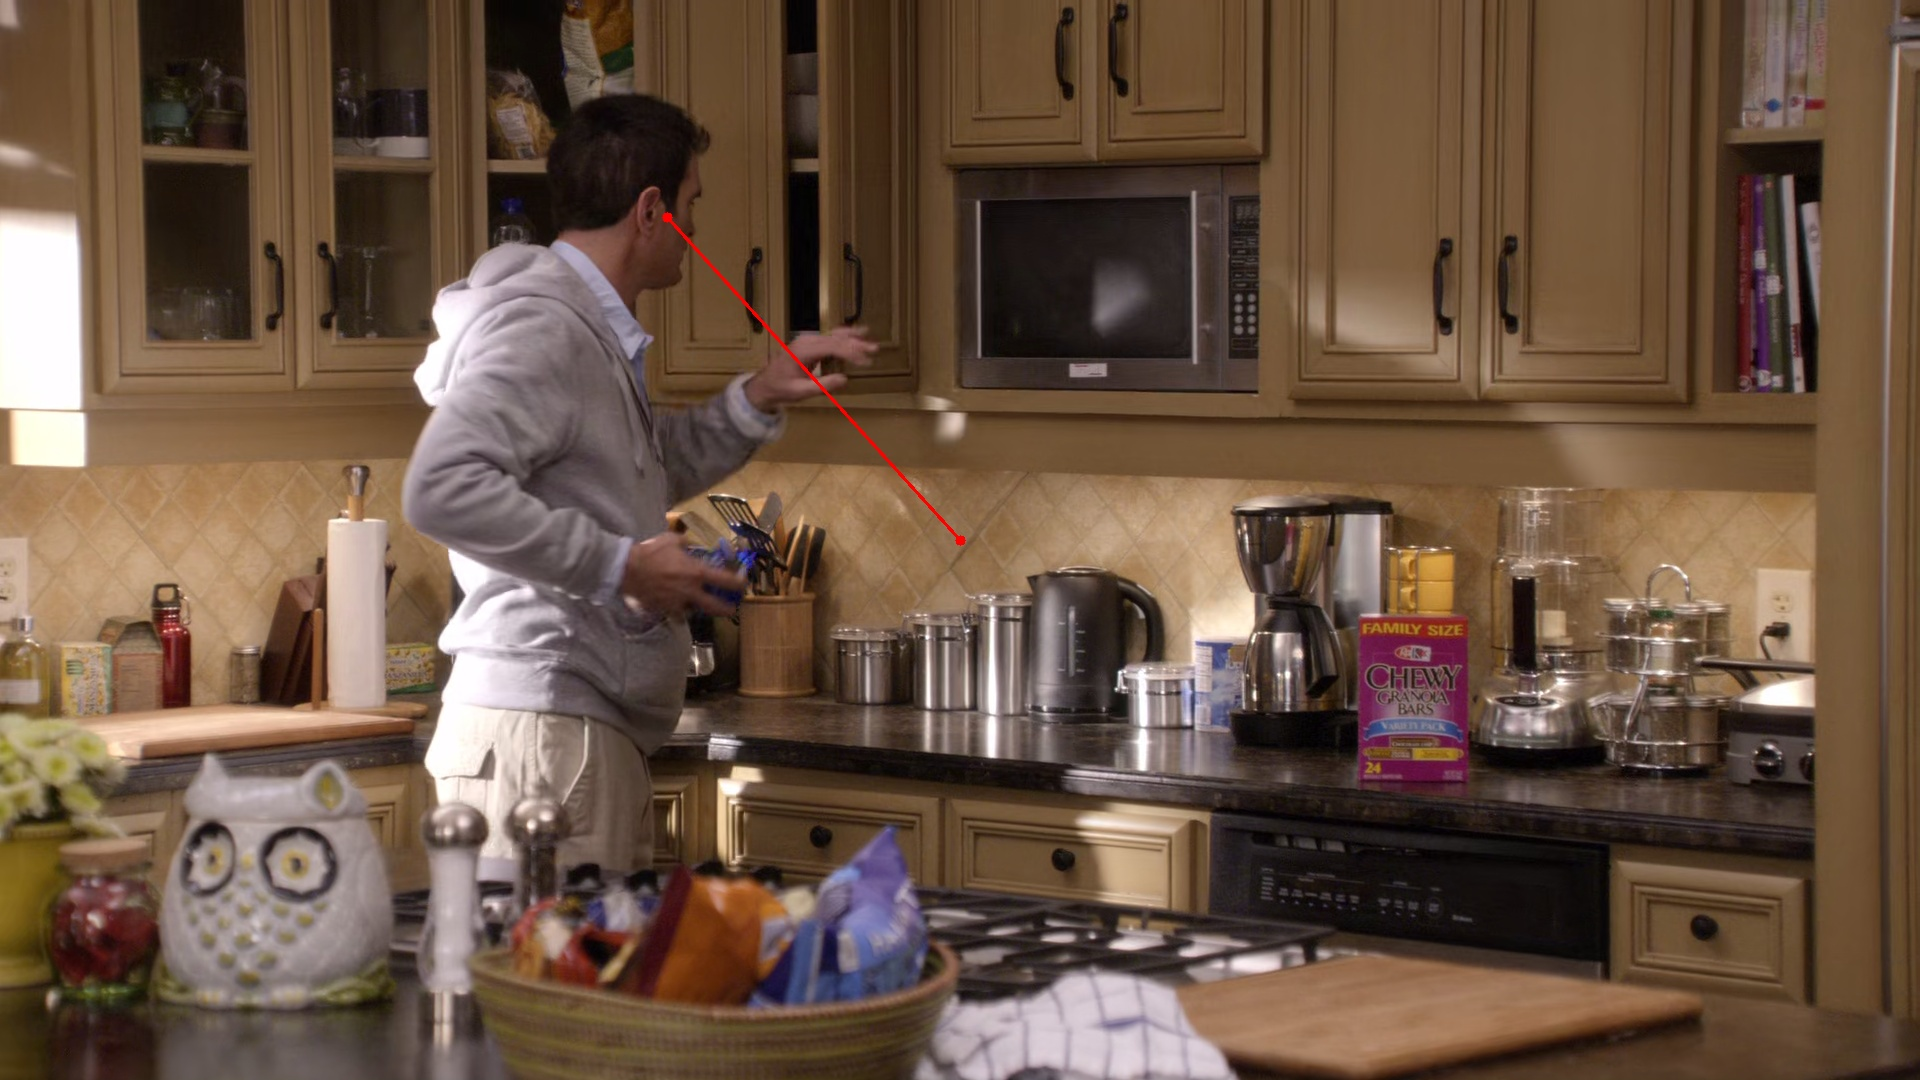

In [22]:
draw_to_center(df.iloc[0])

In [26]:
row = df.iloc[0]
x = row['x2'] - row['x1']
y = row['y2'] - row['y1']
# xx = x * row['img_width']
# yy = y * row['img_height']

pct_of_frame = (x * y)
print(pct_of_frame * 100)

0.4234999999999998


In [34]:
row = df.iloc[100]
x = int((row['x2'] - row['x1']) * row['img_width'])
y = int((row['y2'] - row['y1']) * row['img_height'])
xx = row['img_width']
yy = row['img_height']

pct = (x * y)/(xx * yy)
print(pct * 100)

2.961082175925926


In [38]:
pct_of_frame(row)

2.96

In [39]:
distance_from_center(row)

209.82

In [23]:
get_episode_info(file)

(8, 5)

In [3]:
df = pd.read_csv("/home/amos/programs/CineFace/data/faces/king-of-the-hill_1997_118375/King.of.the.Hill.S08E09.Ceci.N'est.Pas.Une.King.of.the.Hill.480p.DVDRip.10bit.x265.HEVC.DD2.0-PHOCiS.csv", index_col=0)
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,img_height,filepath,encoding,series_id,episode_id,filename,distance_from_center,pct_of_frame,season,episode
0,0.100,0.246,0.150,0.348,0.119,0.290,0.141,0.286,0.135,0.305,...,480,/home/amos/media/tv/King.of.the.Hill.1997.S01-...,-0.0597836\n0.101134\n0.0157719\n0.0310432\n-0...,118375,NaN,King.of.the.Hill.S08E09.Ceci.N'est.Pas.Une.Kin...,287.24,0.49,8,9
1,0.193,0.281,0.236,0.375,0.214,0.317,0.232,0.316,0.228,0.332,...,480,/home/amos/media/tv/King.of.the.Hill.1997.S01-...,-0.0767554\n0.10685\n0.0313232\n-0.00684888\n-...,118375,NaN,King.of.the.Hill.S08E09.Ceci.N'est.Pas.Une.Kin...,222.09,0.39,8,9
2,0.567,0.269,0.618,0.367,0.575,0.308,0.596,0.307,0.581,0.328,...,480,/home/amos/media/tv/King.of.the.Hill.1997.S01-...,-0.0929369\n0.0636445\n0.107424\n0.072956\n-0....,118375,NaN,King.of.the.Hill.S08E09.Ceci.N'est.Pas.Une.Kin...,110.00,0.49,8,9
3,0.567,0.269,0.618,0.367,0.575,0.308,0.595,0.308,0.580,0.328,...,480,/home/amos/media/tv/King.of.the.Hill.1997.S01-...,-0.0788202\n0.0430928\n0.0834469\n0.0882038\n-...,118375,NaN,King.of.the.Hill.S08E09.Ceci.N'est.Pas.Une.Kin...,110.00,0.49,8,9
4,0.199,0.281,0.243,0.373,0.219,0.318,0.238,0.316,0.234,0.331,...,480,/home/amos/media/tv/King.of.the.Hill.1997.S01-...,-0.0765001\n0.0679021\n-0.00797951\n-0.0258062...,118375,NaN,King.of.the.Hill.S08E09.Ceci.N'est.Pas.Une.Kin...,217.85,0.39,8,9


In [4]:
df[df['encoding'].isna()]

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,img_height,filepath,encoding,series_id,episode_id,filename,distance_from_center,pct_of_frame,season,episode
413,0.310,0.344,0.525,0.733,0.347,0.492,0.445,0.474,0.385,0.558,...,480,/home/amos/media/tv/King.of.the.Hill.1997.S01-...,NaN,118375,NaN,King.of.the.Hill.S08E09.Ceci.N'est.Pas.Une.Kin...,62.64,8.29,8,9
414,0.314,0.331,0.535,0.733,0.351,0.489,0.444,0.471,0.386,0.553,...,480,/home/amos/media/tv/King.of.the.Hill.1997.S01-...,NaN,118375,NaN,King.of.the.Hill.S08E09.Ceci.N'est.Pas.Une.Kin...,57.01,8.83,8,9
415,0.308,0.306,0.526,0.704,0.346,0.452,0.443,0.441,0.380,0.521,...,480,/home/amos/media/tv/King.of.the.Hill.1997.S01-...,NaN,118375,NaN,King.of.the.Hill.S08E09.Ceci.N'est.Pas.Une.Kin...,60.03,8.62,8,9
416,0.097,0.467,0.157,0.594,0.108,0.529,0.132,0.528,0.117,0.556,...,480,/home/amos/media/tv/King.of.the.Hill.1997.S01-...,NaN,118375,NaN,King.of.the.Hill.S08E09.Ceci.N'est.Pas.Une.Kin...,269.36,0.75,8,9
417,0.621,0.262,0.674,0.398,0.632,0.313,0.633,0.311,0.625,0.340,...,480,/home/amos/media/tv/King.of.the.Hill.1997.S01-...,NaN,118375,NaN,King.of.the.Hill.S08E09.Ceci.N'est.Pas.Une.Kin...,134.01,0.71,8,9
